In [211]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import jensenshannon
import torch
import torch.nn as nn
import random
import seaborn as sns

# prepare the labels y

In [212]:
dataset = pd.read_parquet('../kinpfn_testing_set/parquet_parsing/test_val_dataset.parquet')

In [213]:
arr_fpts = np.array([row for row in dataset['fpts']])

In [214]:
arr_fpts.shape

(2654, 1000)

In [215]:
np.min(arr_fpts)

np.float64(0.0)

In [216]:
np.max(arr_fpts)

np.float64(297458098.413)

In [217]:
np.where(arr_fpts == 0)

(array([ 251,  258,  274,  274,  274,  274,  274,  274,  274,  333,  349,
         349,  453,  459,  464,  465,  465,  465,  465,  478,  480,  480,
         482,  484,  484,  484,  484,  491,  491,  491,  491,  527, 1373,
        1441, 1490, 1490, 1490, 1497, 1510, 1510, 1510, 1514, 1514, 1531,
        1897, 2157, 2167, 2167, 2179, 2183, 2201, 2220, 2235, 2245, 2248,
        2253, 2253, 2255, 2256, 2256, 2257, 2267, 2282, 2282, 2282, 2295,
        2296, 2296, 2298, 2298, 2316, 2316, 2322, 2328, 2328, 2328, 2355,
        2355, 2361, 2361, 2361, 2381, 2381, 2390, 2446]),
 array([ 81, 180, 186, 211, 222, 408, 472, 555, 965, 153, 412, 864, 560,
         11, 389,  66, 250, 625, 641, 903, 420, 612, 230, 276, 306, 452,
        783,  40, 141, 432, 792, 643, 805, 460, 148, 175, 728, 730, 208,
        270, 368, 777, 928, 529, 320, 454, 468, 774, 626,  53, 920, 921,
        808, 525, 892, 135, 360, 589, 617, 702, 865, 711,  70, 601, 719,
        792, 226, 597, 553, 751,   8, 332, 531, 396, 552, 6

In [218]:
where_arr_fpts_nonzero = np.where(arr_fpts != 0)
arr_logfpts = np.log10(arr_fpts[where_arr_fpts_nonzero])

In [219]:
np.min(arr_logfpts)

np.float64(-3.0)

In [220]:
np.max(arr_logfpts)

np.float64(8.473425797258969)

In [221]:
arr_logfpts.shape

(2653915,)

In [222]:
n_bins = 50

binedges_logfpt = np.linspace(np.min(arr_logfpts), np.max(arr_logfpts), n_bins+1)

In [223]:
arr_hist_logfpts = np.zeros((dataset.shape[0], n_bins))
for index, row in dataset.iterrows():
    fpts = row['fpts']
    where_fpts_nonzero = np.where(fpts != 0)
    logfpts = np.log10(fpts[where_fpts_nonzero])
    hist_logfpts, _ = np.histogram(logfpts, binedges_logfpt, density=True)
    hist_logfpts /= np.sum(hist_logfpts) # normalize so that values add to 1; this does not reflect the probability density
    arr_hist_logfpts[index] = hist_logfpts


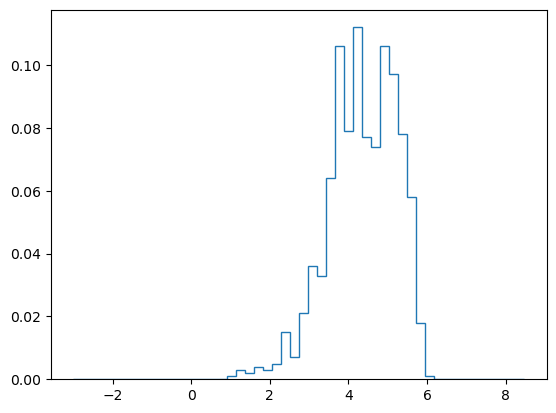

In [224]:
plt.stairs(arr_hist_logfpts[67], binedges_logfpt)

In [225]:
y = arr_hist_logfpts

In [226]:
np.sum(y, axis=1)

array([1., 1., 1., ..., 1., 1., 1.], shape=(2654,))

In [227]:
print(y.shape)

(2654, 50)


# prepare the features X

In [228]:
print(dataset.columns)

Index(['filepath', 'sequence', 'length', 'mfe_from_file',
       'dot_bracket_from_file', 'fpts', 'gc_content', 'freq_A', 'freq_U',
       'freq_G',
       ...
       'min_11_tree_dist', 'min_12_tree_dist', 'min_13_tree_dist',
       'min_14_tree_dist', 'min_15_tree_dist', 'min_16_tree_dist',
       'min_17_tree_dist', 'min_18_tree_dist', 'min_19_tree_dist',
       'min_20_tree_dist'],
      dtype='object', length=110)


In [229]:
X = dataset.drop(columns=['filepath', 'sequence', 'dot_bracket_from_file', 'fpts', 'mfe_structure', 'mfe'])
for i in range(1, 21):
    X = X.drop(columns=['min_'+str(i)+'_structure'])
    X = X.drop(columns=['min_'+str(i)+'_energy'])
    X = X.drop(columns=['min_'+str(i)+'_bp_dist'])
    X = X.drop(columns=['min_'+str(i)+'_tree_dist'])

In [230]:
X.shape

(2654, 24)

In [231]:
feature_names = X.columns.values.tolist()

In [232]:
print(feature_names)

['length', 'mfe_from_file', 'gc_content', 'freq_A', 'freq_U', 'freq_G', 'freq_C', 'freq_AA', 'freq_AU', 'freq_AG', 'freq_AC', 'freq_UA', 'freq_UU', 'freq_UG', 'freq_UC', 'freq_GA', 'freq_GU', 'freq_GG', 'freq_GC', 'freq_CA', 'freq_CU', 'freq_CG', 'freq_CC', 'n_local_minima']


In [233]:
X.shape

(2654, 24)

In [234]:
X = np.array(X)

In [235]:
X.shape

(2654, 24)

In [236]:
y.shape

(2654, 50)

# train the model

In [237]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [238]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [239]:
class GLM(nn.Module):
    def __init__(self, input_dim, n_bins=50):
        super().__init__()
        self.linear = nn.Linear(input_dim, n_bins)
    
    def forward(self, x):
        return self.linear(x)  # return logits; apply log_softmax in loss

In [240]:
X_train.shape

(1916, 24)

In [241]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

In [242]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
def weights_changed(model, prev_weights, tol=1e-6):
    current_weights = torch.cat([p.data.flatten() fo p in model.parameters()])
    return torch.norm(current_weights - prev_weights).item() > tol

epoch 1: train_loss = 1.4606614112854004, val_loss = 1.1834365129470825
epoch 100: train_loss = 0.4469950795173645, val_loss = 0.46905162930488586
epoch 200: train_loss = 0.43734195828437805, val_loss = 0.45817697048187256
epoch 300: train_loss = 0.4333152770996094, val_loss = 0.45264193415641785
epoch 400: train_loss = 0.4310072064399719, val_loss = 0.449283242225647
epoch 500: train_loss = 0.4295845925807953, val_loss = 0.4472368657588959
epoch 600: train_loss = 0.4285793602466583, val_loss = 0.44556596875190735
epoch 700: train_loss = 0.4279332756996155, val_loss = 0.44459637999534607
epoch 800: train_loss = 0.4275396764278412, val_loss = 0.4442373514175415
epoch 900: train_loss = 0.4272436201572418, val_loss = 0.4436711370944977
Converged at epoch 1000: train_loss = 0.4270828068256378, val_loss = 0.44315749406814575


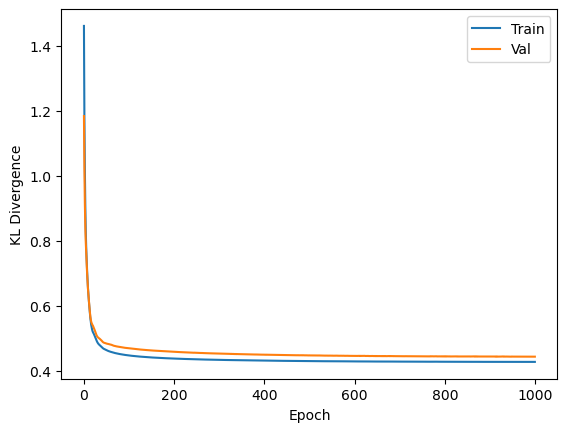

<Figure size 640x480 with 0 Axes>

In [290]:
set_seed(42)

model = GLM(input_dim=X_train.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-1, weight_decay=1e-5)
loss_fn = nn.KLDivLoss(reduction='batchmean')  # soft targets

train_losses, val_losses = [], []

max_num_epochs = 1000

epoch = 0
while True:
    prev_weights = torch.cat([p.data.flatten() for p in model.parameters()]).clone()

    model.train()

    log_probs = torch.log_softmax(model(X_train_t), dim=-1)
    loss = loss_fn(log_probs, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        log_probs_val = torch.log_softmax(model(X_val_t), dim=-1)
        val_loss = loss_fn(log_probs_val, y_val_t)
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    epoch += 1
    
    if (epoch >= max_num_epochs) or (not weights_changed(model, prev_weights, tol=1e-6)):
        print(f'Converged at epoch {epoch}: train_loss = {train_losses[-1]}, val_loss = {val_losses[-1]}')
        break

    if (epoch == 1) or (epoch > 1 and epoch % 100 == 0):
        print(f'epoch {epoch}: train_loss = {train_losses[-1]}, val_loss = {val_losses[-1]}')


plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.legend()
plt.show()

plt.savefig('train_glm.pdf', bbox_inches='tight')
plt.savefig('train_glm.png', bbox_inches='tight')

In [280]:
i = np.random.choice(X_train_t.shape[0])

In [281]:
model.eval()
with torch.no_grad():
    log_probs = torch.log_softmax(model(X_val_t), dim=-1)
    val_loss = loss_fn(log_probs, y_val_t)
    print(f"Val KL divergence: {val_loss.item():.4f}")

Val KL divergence: 0.4432


In [282]:
model.eval()
with torch.no_grad():
    probs = torch.softmax(model(X_val_t), dim=-1).numpy()

js_scores = [jensenshannon(y_val[i], probs[i]) for i in range(len(y_val))]
print(f"Mean JS divergence: {np.mean(js_scores):.4f}")
print(f"Median JS divergence: {np.median(js_scores):.4f}")

Mean JS divergence: 0.3232
Median JS divergence: 0.3154


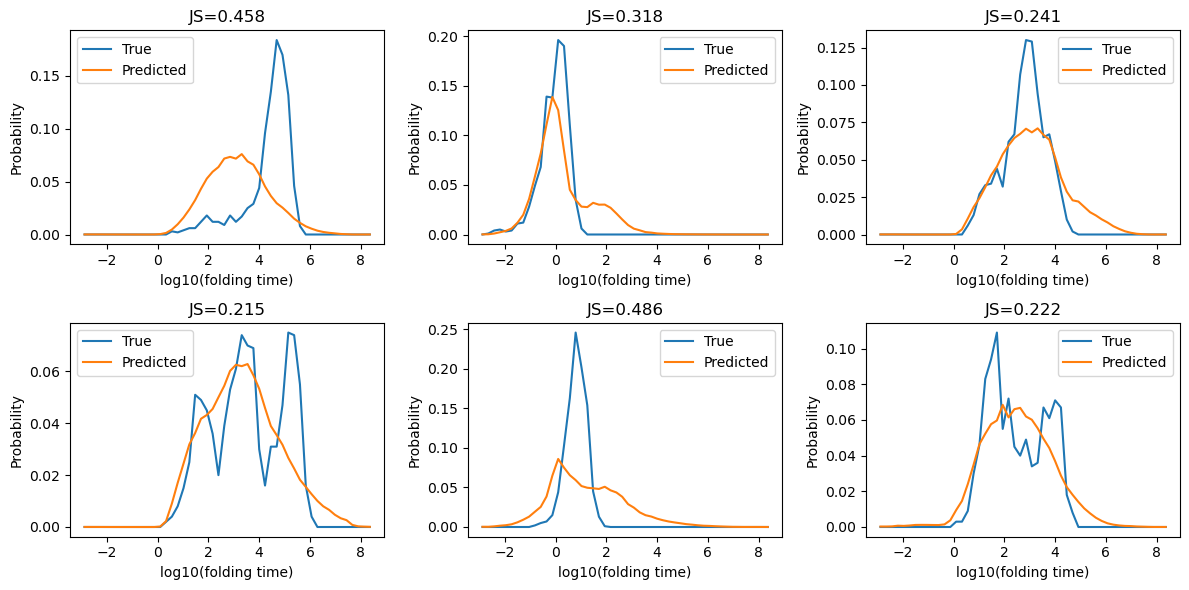

In [294]:
bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(bin_centers, y_val[10*i], label='True')
    #print(np.sum(y_val[i]))
    ax.plot(bin_centers, probs[10*i], label='Predicted')
    #print(np.sum(probs[i]))
    ax.set_title(f"JS={js_scores[10*i]:.3f}")
    ax.set_xlabel('log10(folding time)')
    ax.set_ylabel('Probability')
    ax.legend()
plt.tight_layout()
plt.show()

In [284]:
torch.save(model.state_dict(), 'glm_weights.pth')

In [285]:
model2 = GLM(input_dim=X_train.shape[1])
state_dict = torch.load('glm_weights.pth')
model2.load_state_dict(state_dict)

<All keys matched successfully>

In [286]:
for name, param in model2.named_parameters():
    print(f"Layer: {name} | Size: {param.size()}")

Layer: linear.weight | Size: torch.Size([50, 24])
Layer: linear.bias | Size: torch.Size([50])


In [287]:
params = list(model2.parameters())
weights = params[0].detach().numpy()
print(weights.shape)
biases = params[1].detach().numpy()
print(biases.shape)
biases = biases.reshape((biases.shape[0], 1))
print(biases.shape)
biases_weights = np.hstack((weights,biases))
print(biases_weights.shape)

(50, 24)
(50,)
(50, 1)
(50, 25)


In [288]:
weights_and_biases = np.hstack((weights,biases))
print(weights_and_biases.shape)

(50, 25)


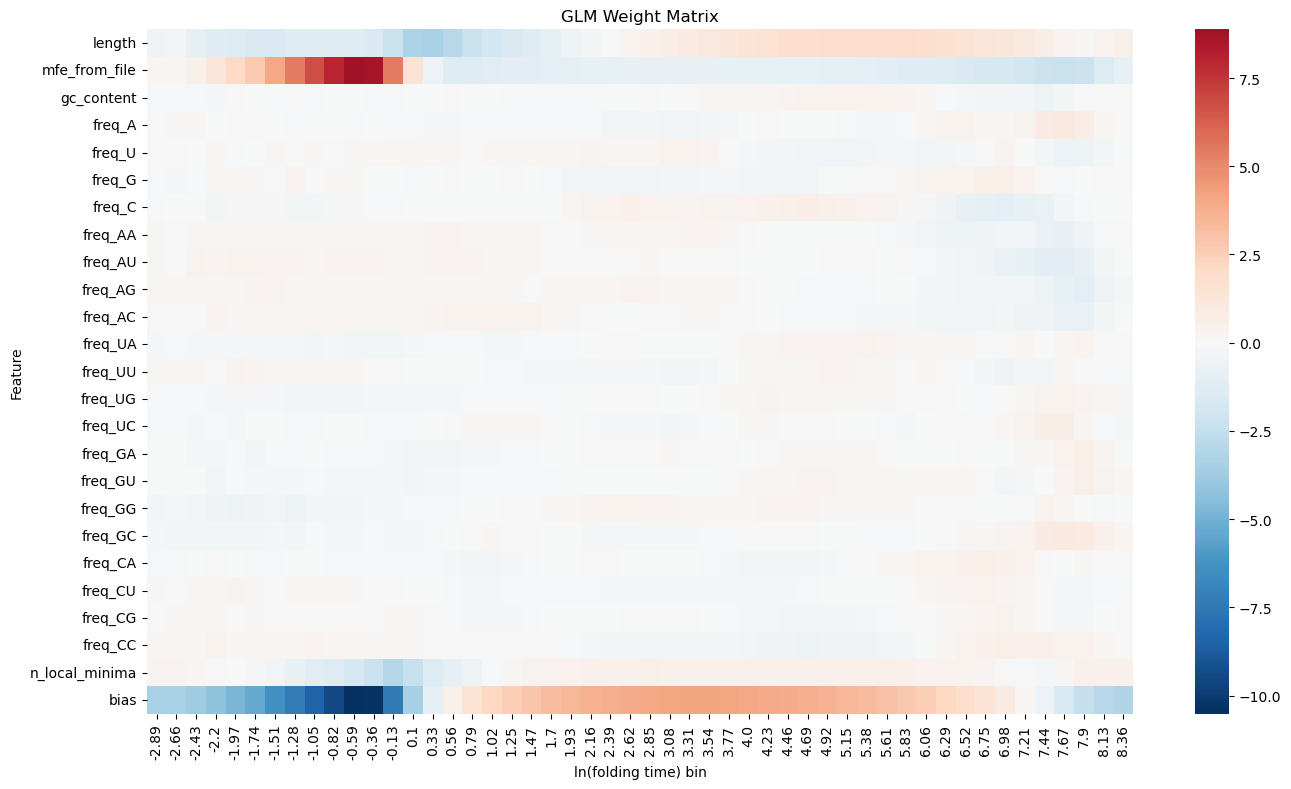

In [289]:
bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(weights_and_biases.T, xticklabels=bin_centers.round(2), yticklabels=feature_names+['bias'],
           cmap='RdBu_r', center=0, ax=ax)
# sns.heatmap(weights.T, xticklabels=bin_centers.round(2),
#             cmap='RdBu_r', center=0, ax=ax)
ax.set_xlabel('ln(folding time) bin')
ax.set_ylabel('Feature')
plt.title('GLM Weight Matrix')
plt.tight_layout()
plt.show()

In [171]:
for i in range(24):
    print(X_train[:,i].mean())

print('')
for i in range(24):
    print(X_train[:,i].std())

-1.0754561240627821e-16
2.9111484737561516e-15
-4.0357418172804226e-15
-8.823839362730628e-15
3.1855752088618272e-15
-1.5501402064077343e-15
-2.6997657183369152e-15
-4.477976792433825e-15
-4.848823731765819e-15
-7.963938022154568e-15
-5.293840058964212e-15
-3.2189514334017064e-15
-2.4118957816804547e-15
-3.695489750443318e-15
-5.6999174575327454e-15
-6.536177305726391e-15
-7.505942052079555e-15
-4.097858679618532e-15
-6.02997123353822e-15
-3.62317459727358e-15
-3.2690157702115255e-15
-1.1681678588957805e-15
-5.8797782231087626e-15
-7.416938786639876e-18

1.0000000000000007
0.999999999999999
1.0000000000000002
0.9999999999999997
0.9999999999999998
0.9999999999999994
0.9999999999999964
0.999999999999999
1.0000000000000004
0.999999999999999
0.9999999999999979
0.9999999999999993
1.0000000000000007
1.0000000000000004
1.000000000000002
0.999999999999999
0.9999999999999982
0.9999999999999966
1.0000000000000007
1.0000000000000004
0.9999999999999991
0.9999999999999992
0.9999999999999983
1.0


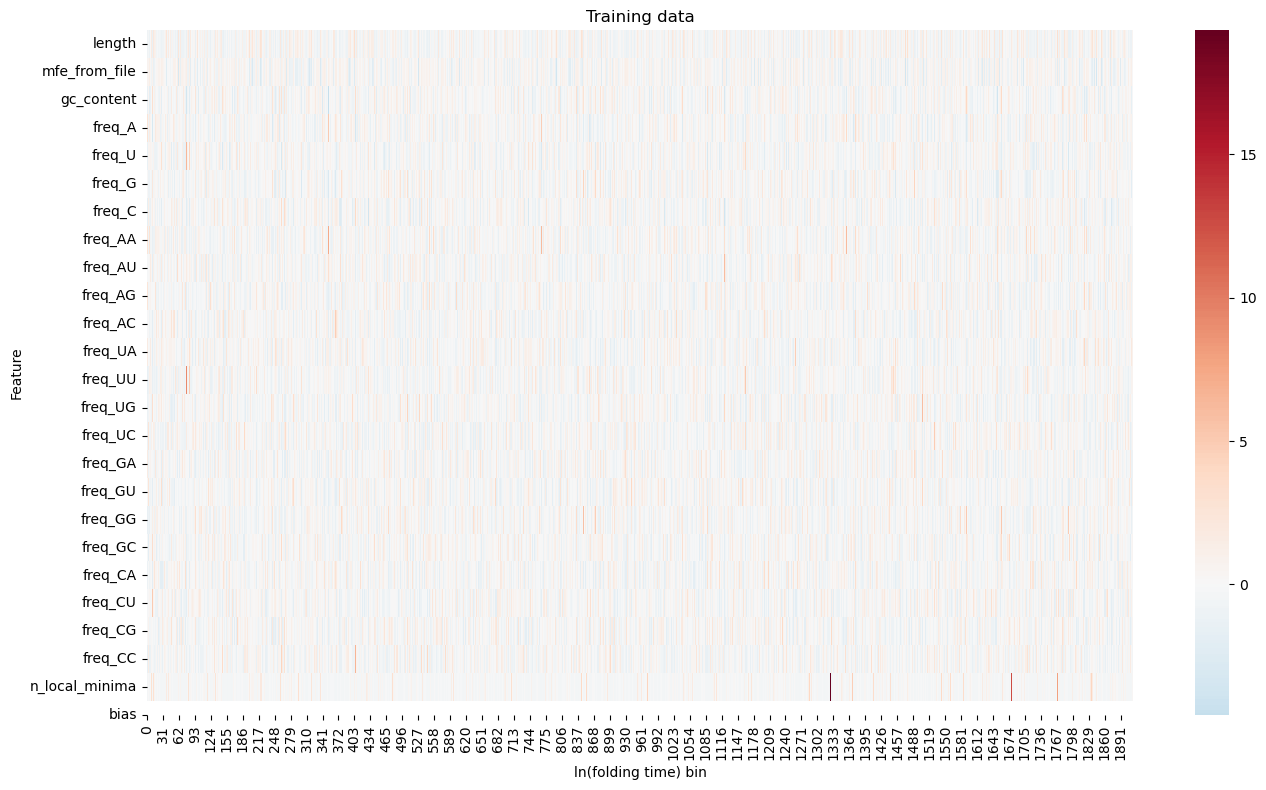

In [ ]:
num_examples_to_show = X_train.shape[0]

fg, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(X_train[0:num_examples_to_shw].T, yticklabels=feature_names+['bias'],
           cmap='RdBu_r', center=0, ax=ax)
# sns.heatmap(weights.T, xticklabels=bin_ceters.round(2),
#             cmap='RdBu_r', center=0, ax=ax)
ax.set_xlabel('ln(folding time) bin')
ax.set_ylabel('Feature')
plt.title('Training data'
plt.tight_layout()
plt.show()

In [278]:
for i in range(len(feature_names)):
  if i != len(feature_names) - 1:
    print(feature_names[i], end = ', ')
  else:
    print(feature_names[i], end = '')

length, mfe_from_file, gc_content, freq_A, freq_U, freq_G, freq_C, freq_AA, freq_AU, freq_AG, freq_AC, freq_UA, freq_UU, freq_UG, freq_UC, freq_GA, freq_GU, freq_GG, freq_GC, freq_CA, freq_CU, freq_CG, freq_CC, n_local_minima